In [1]:
import warnings
import torch
from torch import inference_mode

from dataset import OptionsDataModule
from model import OptionNetModule
import lightning as pl
warnings.filterwarnings("ignore")

In [2]:
CHECKPOINT_PATH = './checkpoints/run_20260217_234449_749029/epoch=299-step=43200.ckpt'
DATA_DIR = "./data/108105"
BATCH_SIZE = 128

data_module = OptionsDataModule(DATA_DIR, sofr_path="./data/sofr.csv", batch_size=BATCH_SIZE)
data_module.setup("fit")

print(f"Loading Model from {CHECKPOINT_PATH}...")
model = OptionNetModule.load_from_checkpoint(CHECKPOINT_PATH)
model.eval()
model.to("mps")

Train moneyness bucket rows -> DEEP: 64675 | OTM: 204936 | ATM: 287482 | ITM: 45251
Train sampler -> balanced across 4 available moneyness buckets per epoch
Date split -> Train: 352 | Validation: 20 | Test: 43
Rows -> Train: 602344 | Validation: 32601 | Test: 71388
Loading Model from ./checkpoints/run_20260217_234449_749029/epoch=299-step=43200.ckpt...


OptionNetModule(
  (model): OptionNet(
    (model): Sequential(
      (0): Linear(in_features=6, out_features=350, bias=True)
      (1): SiLU()
      (2): Linear(in_features=350, out_features=175, bias=True)
      (3): SiLU()
      (4): Linear(in_features=175, out_features=350, bias=True)
      (5): SiLU()
      (6): Linear(in_features=350, out_features=1, bias=True)
      (7): Softplus(beta=1.0, threshold=20.0)
    )
  )
  (loss_fn): GreeksInformedLoss(
    (price_loss): MSELoss()
  )
)

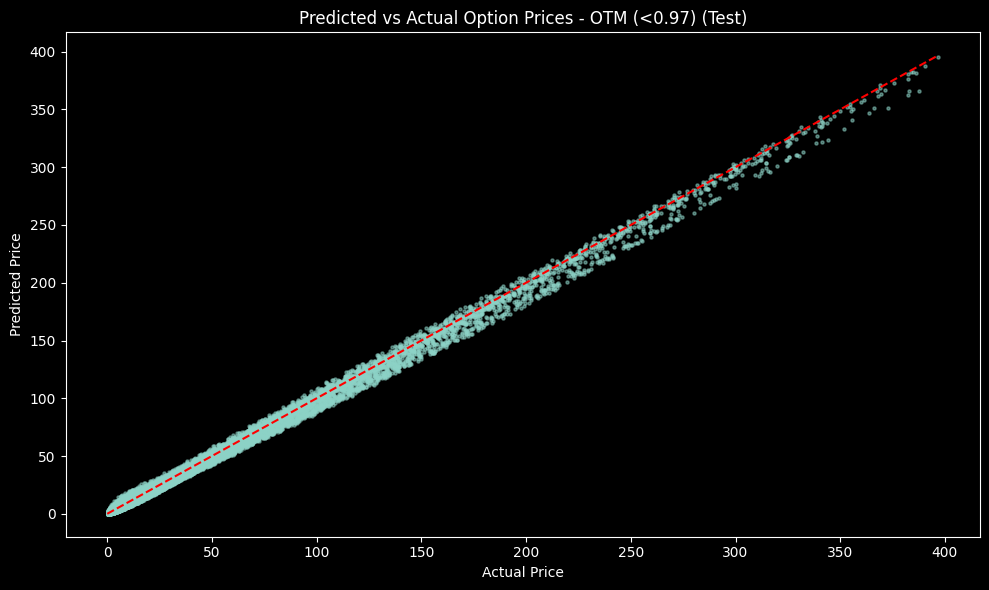

Scatterplot saved to predicted_vs_actual_test_otm.png


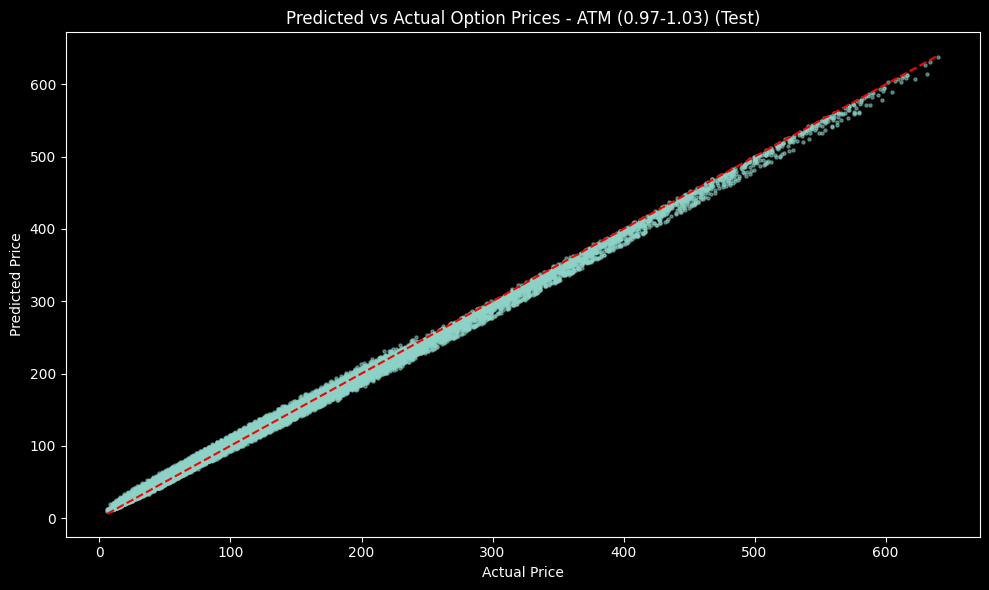

Scatterplot saved to predicted_vs_actual_test_atm.png


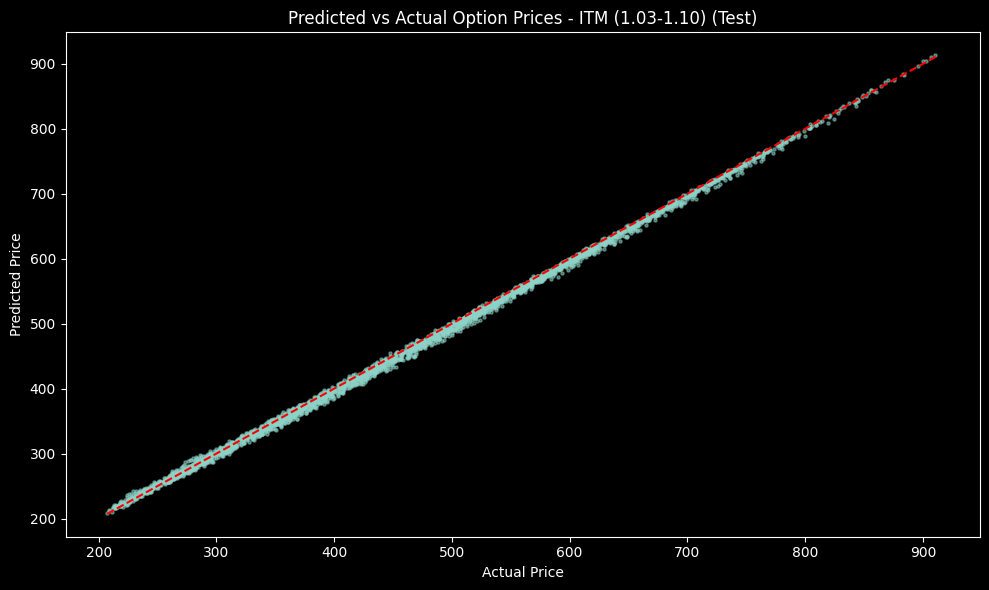

Scatterplot saved to predicted_vs_actual_test_itm.png


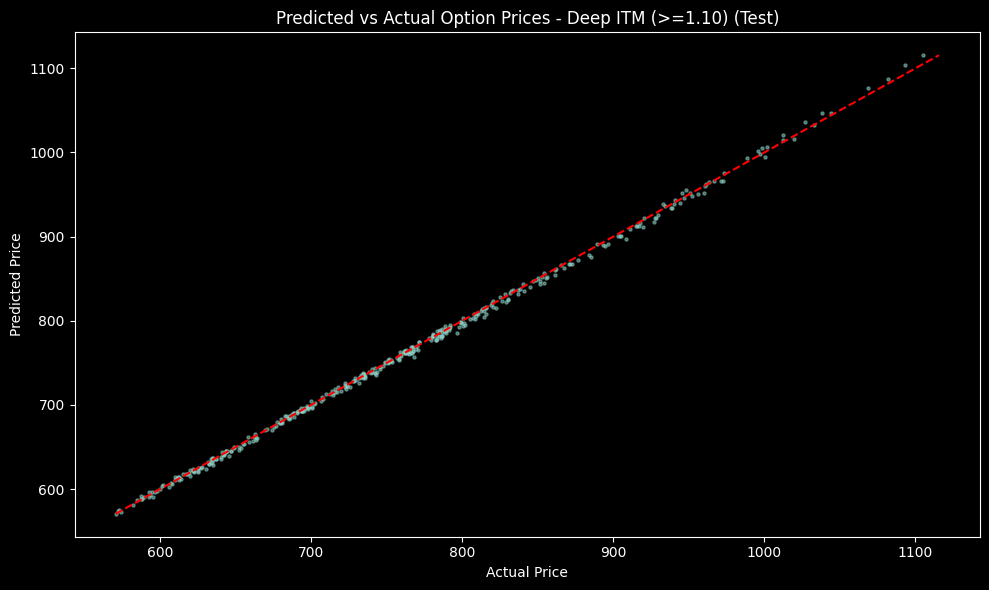

Scatterplot saved to predicted_vs_actual_test_deep_itm.png


In [3]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np

model.eval()
val_loader = data_module.val_dataloader()

all_preds = []
all_actuals = []
all_moneyness = []


for idx, batch in enumerate(val_loader):
    x, y = batch
    mps_x = x.clone().to("mps")
    preds, _ = model(x.to("mps"))
    all_preds.append(preds.detach().cpu().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy())
    all_moneyness.append((x[:, 0] / x[:, 1]).numpy())

all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()
all_moneyness = np.concatenate(all_moneyness).flatten()

bucket_edges = [0.0, 0.97, 1.03, 1.10, np.inf]
bucket_labels = [
    'OTM (<0.97)',
    'ATM (0.97-1.03)',
    'ITM (1.03-1.10)',
    'Deep ITM (>=1.10)'
]
bucket_keys = ['otm', 'atm', 'itm', 'deep_itm']

for lower, upper, label, key in zip(bucket_edges[:-1], bucket_edges[1:], bucket_labels, bucket_keys):
    mask = (all_moneyness >= lower) & (all_moneyness < upper)
    if np.any(mask):
        plt.figure(figsize=(10, 6))
        plt.scatter(all_actuals[mask], all_preds[mask], s=5, alpha=0.5)
        min_val = min(all_actuals[mask].min(), all_preds[mask].min())
        max_val = max(all_actuals[mask].max(), all_preds[mask].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        plt.xlabel('Actual Price')
        plt.ylabel('Predicted Price')
        plt.title(f'Predicted vs Actual Option Prices - {label} (Test)')
        plt.tight_layout()
        output_path = f'predicted_vs_actual_test_{key}.png'
        plt.show()
        print(f"Scatterplot saved to {output_path}")

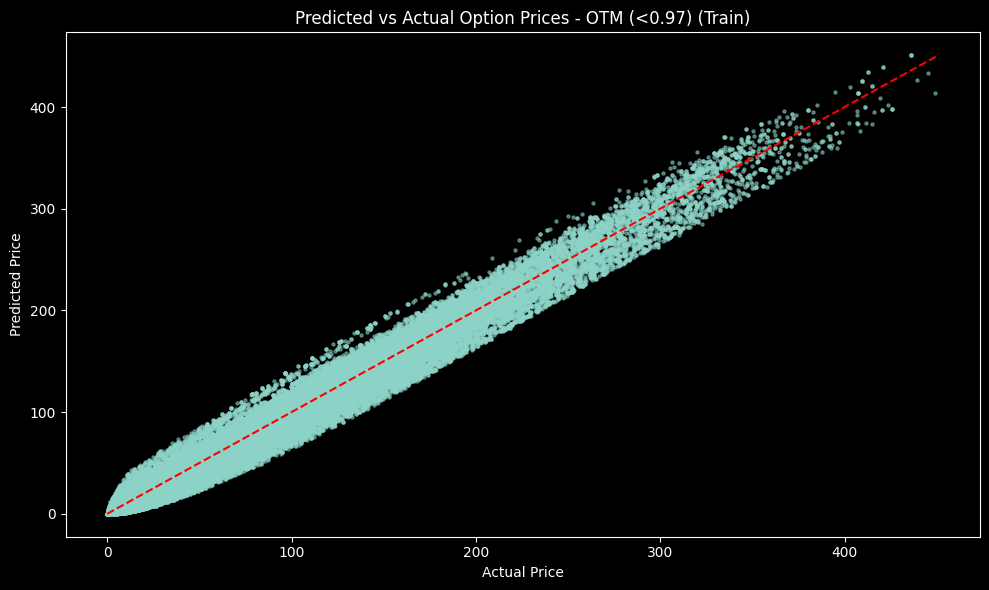

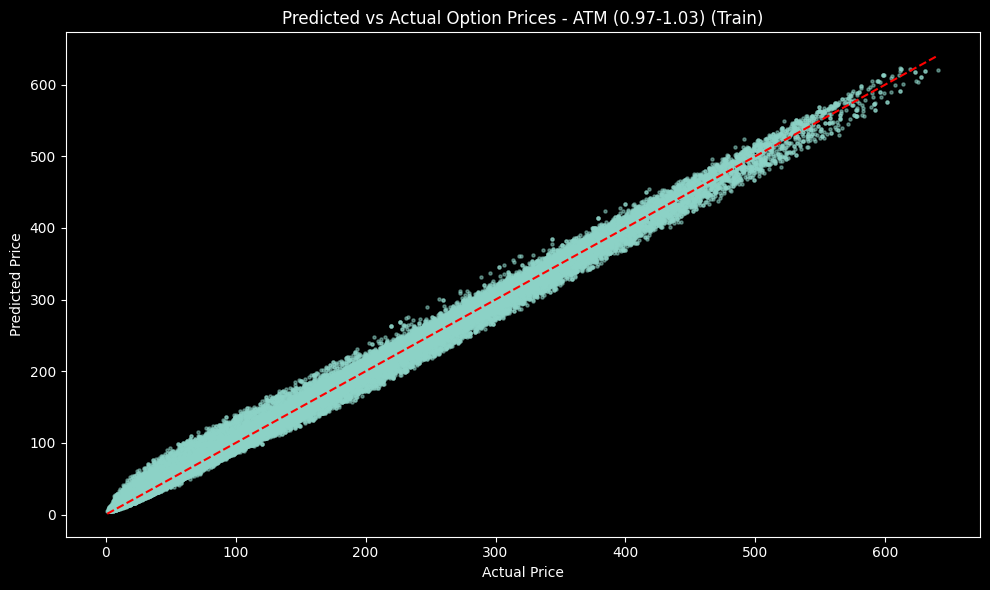

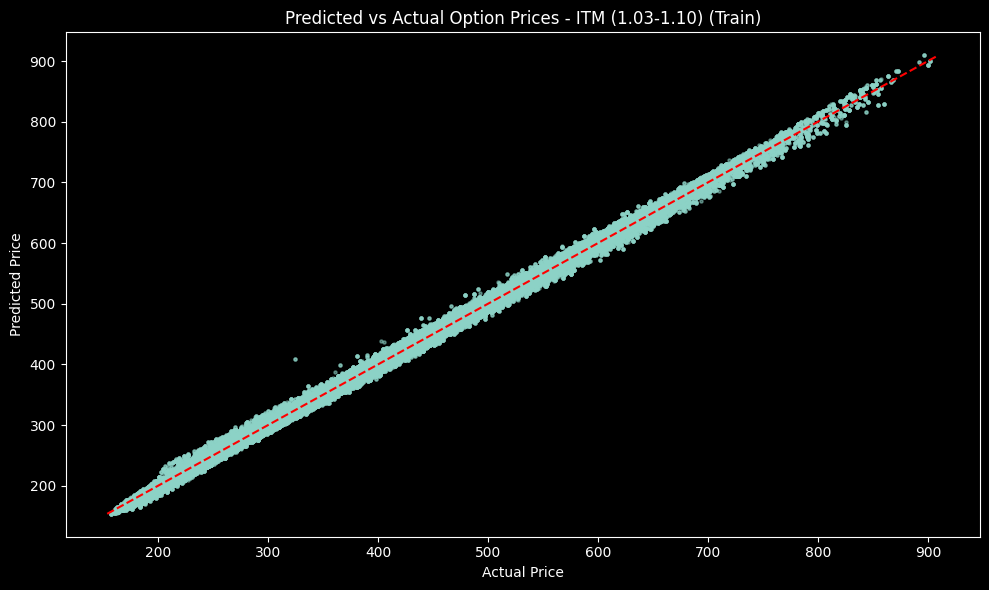

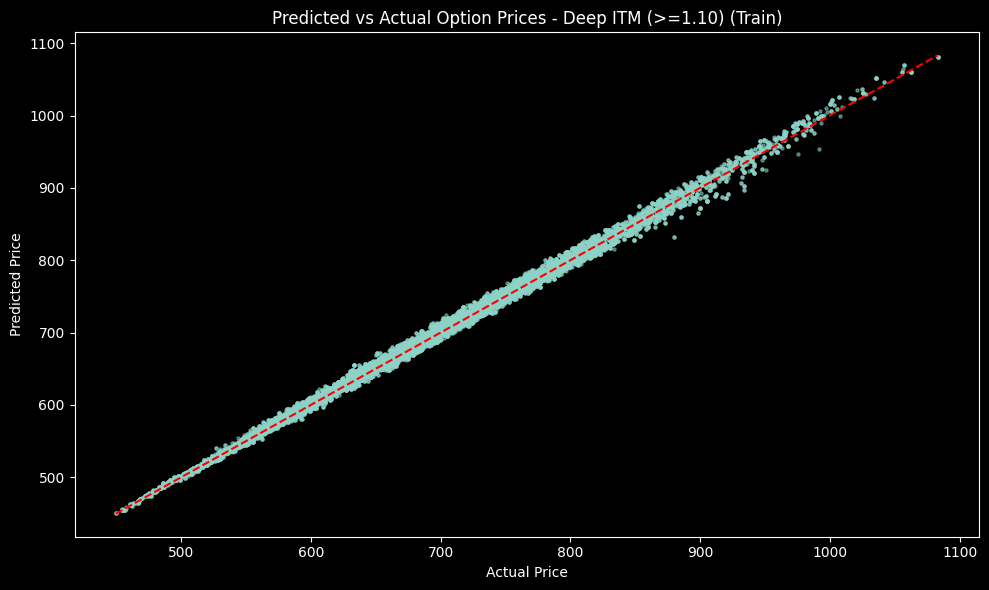

In [4]:
model.eval()
val_loader = data_module.train_dataloader()

all_preds = []
all_actuals = []
all_moneyness = []


for batch in val_loader:
    x, y = batch
    mps_x = x.clone().to("mps")
    preds, _ = model(x.to("mps"))
    all_preds.append(preds.detach().cpu().numpy() * x[:, 1].numpy().reshape(-1, 1))
    all_actuals.append(y.numpy())
    all_moneyness.append((x[:, 0] / x[:, 1]).numpy())

all_preds = np.concatenate(all_preds).flatten()
all_actuals = np.concatenate(all_actuals).flatten()
all_moneyness = np.concatenate(all_moneyness).flatten()

bucket_edges = [0.0, 0.97, 1.03, 1.10, np.inf]
bucket_labels = [
    'OTM (<0.97)',
    'ATM (0.97-1.03)',
    'ITM (1.03-1.10)',
    'Deep ITM (>=1.10)'
]
bucket_keys = ['otm', 'atm', 'itm', 'deep_itm']

for lower, upper, label, key in zip(bucket_edges[:-1], bucket_edges[1:], bucket_labels, bucket_keys):
    mask = (all_moneyness >= lower) & (all_moneyness < upper)
    if np.any(mask):
        plt.figure(figsize=(10, 6))
        plt.scatter(all_actuals[mask], all_preds[mask], s=5, alpha=0.5)
        min_val = min(all_actuals[mask].min(), all_preds[mask].min())
        max_val = max(all_actuals[mask].max(), all_preds[mask].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        plt.xlabel('Actual Price')
        plt.ylabel('Predicted Price')
        plt.title(f'Predicted vs Actual Option Prices - {label} (Train)')
        plt.tight_layout()
        output_path = f'predicted_vs_actual_train_{key}.png'
        plt.show()
